# Introduction to Visualization with Pandas

Python has many powerful visualization libraries: **Matplotlib**, **Seaborn**, and **Plotly** are among the most popular for production-quality plots. But when you just want a quick look at your data during exploration, **Pandas has plotting built right in**.

The Pandas `.plot()` method is built on top of Matplotlib and lets you create common chart types directly from a DataFrame or Series, without writing separate Matplotlib code. This is especially useful for **Exploratory Data Analysis (EDA)**, the process of getting a feel for your data before doing any modelling.

In this notebook we'll use the same red wine quality dataset from the previous notebook to explore four plot types: **histograms**, **scatter plots**, **box plots**, and **bar charts**. Matplotlib will be covered in more depth in a later course, here it is purely a display tool.

## Learning Objectives

By the end of this notebook you will be able to:

1. Create plots from a DataFrame using the `.plot()` method

2. Choose the right chart type for a given question (histogram, scatter, box plot, bar)

3. Interpret basic visualisations and draw conclusions from them

4. Combine Pandas data operations (groupby, filtering) with plotting

---

## Setup

In [1]:
# Load pandas and the wine dataset
# Note: this CSV uses semicolons as delimiters, not commas
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/winequality-red.csv", delimiter=";")

# Create total_acidity column. Useful Later.
df["total_acidity"] = df["fixed acidity"] + df["volatile acidity"]

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,total_acidity
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,8.10
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,8.68
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,8.56
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,11.48
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,8.10


In [2]:
# Review the column names
df.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'total_acidity'],
      dtype='str')

The dataset has 11 physicochemical input features and one output: `quality` (a score from 0 to 10).

See the [UCI dataset page](https://archive.ics.uci.edu/ml/datasets/wine+quality) for full column descriptions.

---

## Histograms

A **histogram** shows the distribution of a single numeric variable, how many observations fall into each value range (bin). It answers the question: *"What does the spread of this variable look like?"*

Use `kind='hist'` in `.plot()` to draw one.

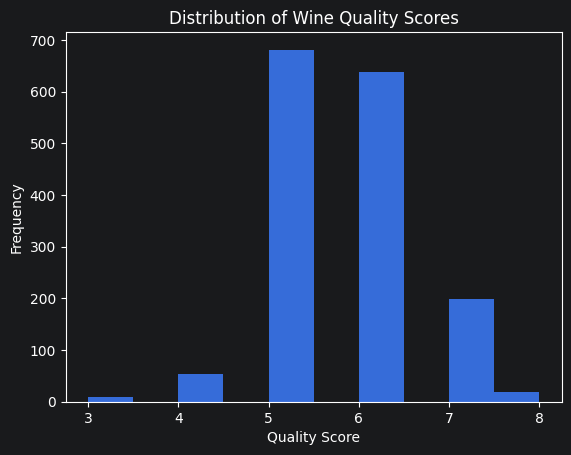

In [3]:
# Histogram of wine quality scores
df["quality"].plot(kind="hist", title="Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.show()

The quality scores range from 3 to 8. Most wines score 5, almost 700 wines received that score. Very high or very low quality wines are rare in this dataset.

---

## Scatter Plots

A **scatter plot** shows the relationship between two numeric variables. Each point represents one observation. It answers the question: *"Does variable A increase or decrease as variable B changes?"*

Use `kind='scatter'` and specify `x` and `y` column names.

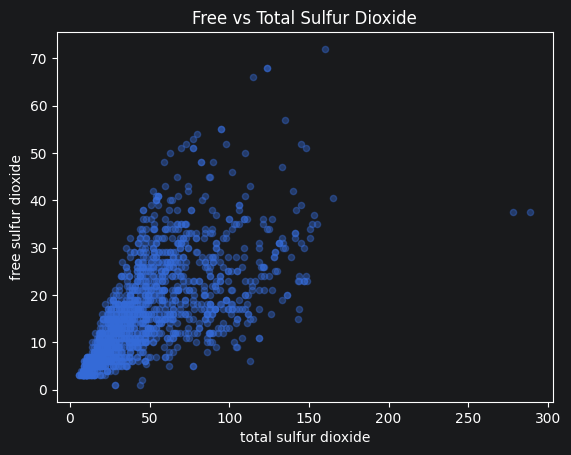

In [4]:
# Scatter: free sulfur dioxide vs total sulfur dioxide
df.plot(
    kind="scatter",
    x="total sulfur dioxide",
    y="free sulfur dioxide",
    title="Free vs Total Sulfur Dioxide",
    alpha=0.4,
)
plt.show()

There is a clear positive relationship: as total sulfur dioxide increases, free sulfur dioxide tends to increase as well.

Now let's look at how alcohol content relates to quality, a discrete variable, so the pattern will look different.

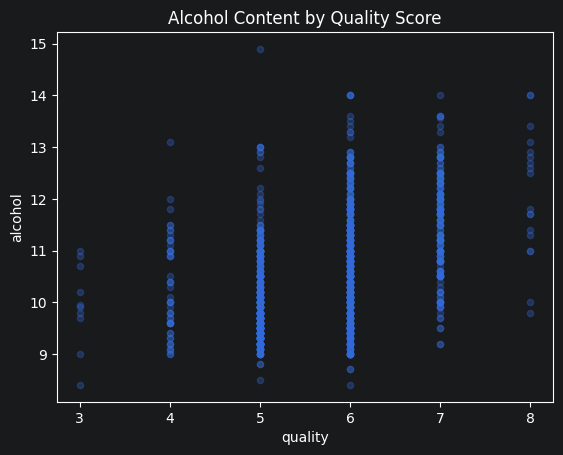

In [5]:
# Scatter: quality vs alcohol, quality is discrete so points cluster in columns
df.plot(
    kind="scatter",
    x="quality",
    y="alcohol",
    title="Alcohol Content by Quality Score",
    alpha=0.3,
)
plt.show()

Higher-quality wines tend to have higher alcohol content. Low-quality wines (score 3–4) rarely appear above 12% alcohol.

---

## Box Plots

A **box plot** summarises the distribution of a variable: the box shows the interquartile range (Q1 to Q3), the line inside is the median, and the whiskers extend to the min and max (excluding outliers). It answers: *"How spread out is this data, and are there outliers?"*

Use `kind='box'`.

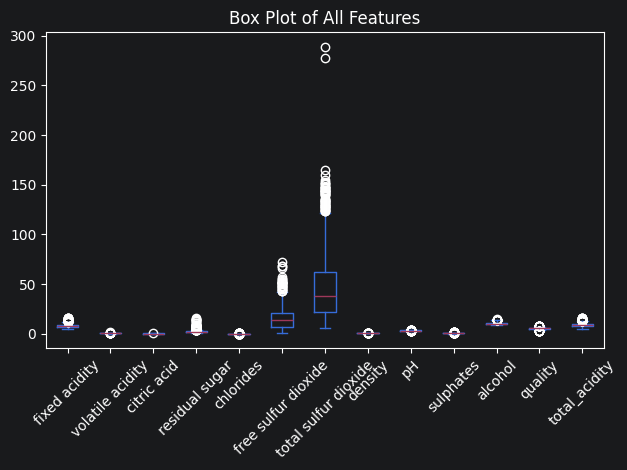

In [6]:
# Box plot of all columns, hard to read because scales differ widely
df.plot(kind="box", title="Box Plot of All Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

When columns have very different scales, a combined box plot is hard to read. Select a subset of columns with similar ranges.

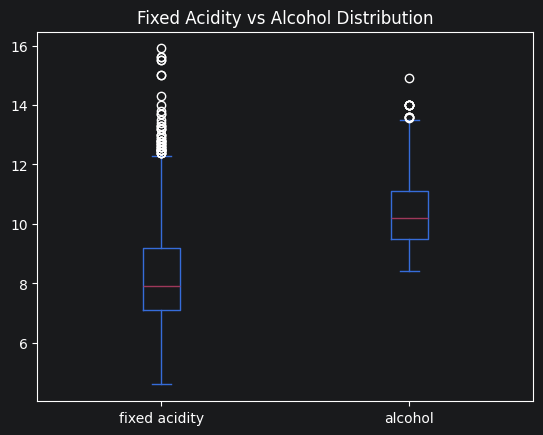

In [7]:
# Compare fixed acidity and alcohol on the same scale
df[["fixed acidity", "alcohol"]].plot(
    kind="box", title="Fixed Acidity vs Alcohol Distribution"
)
plt.show()

---

## Bar Charts

A **bar chart** is ideal for showing aggregated values, like the average of a column for each category. Use `kind='bar'` or `kind='barh'` (horizontal).

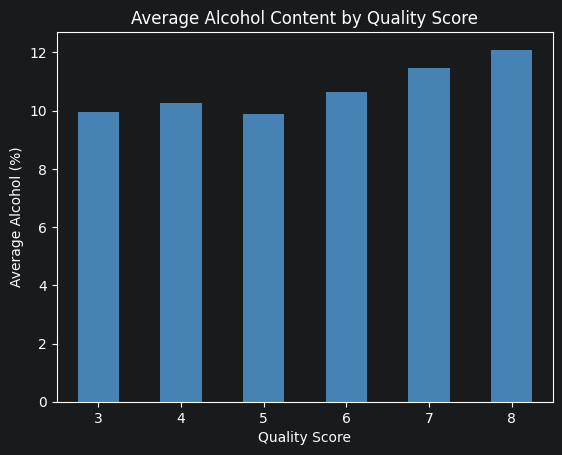

In [8]:
# Average alcohol content by quality, combine groupby with plotting
df.groupby("quality")["alcohol"].mean().plot(
    kind="bar",
    title="Average Alcohol Content by Quality Score",
    color="steelblue",
    rot=0,
)
plt.xlabel("Quality Score")
plt.ylabel("Average Alcohol (%)")
plt.show()

The trend is clear: higher-quality wines consistently have higher average alcohol content.

---

## Practice Challenges

Now it's your turn. Use the [Pandas visualization documentation](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html) as a reference and try to find new insights in the data.

### Challenge 1: Average chlorides by quality, bar chart

Plot the average `chlorides` value for each `quality` score as a bar chart.

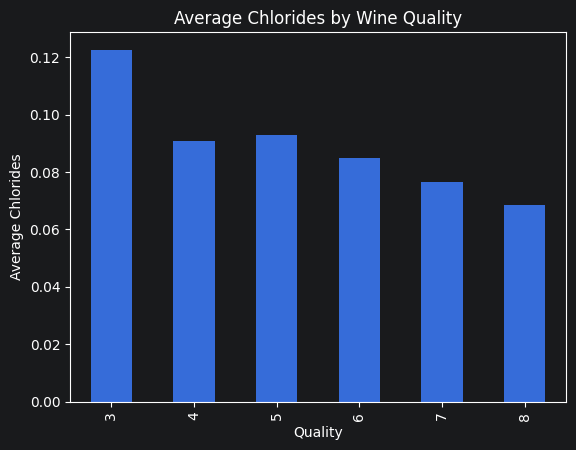

In [9]:
# YOUR CODE HERE
df.groupby("quality")["chlorides"].mean().plot(kind="bar")

plt.xlabel("Quality")
plt.ylabel("Average Chlorides")
plt.title("Average Chlorides by Wine Quality")
plt.show()

### Challenge 2: Alcohol vs pH, scatter plot

Create a scatter plot of `alcohol` (y-axis) against `pH` (x-axis). Does there appear to be any relationship between the two?

<Axes: title={'center': 'Alcohol vs pH'}, xlabel='pH', ylabel='Alcohol'>

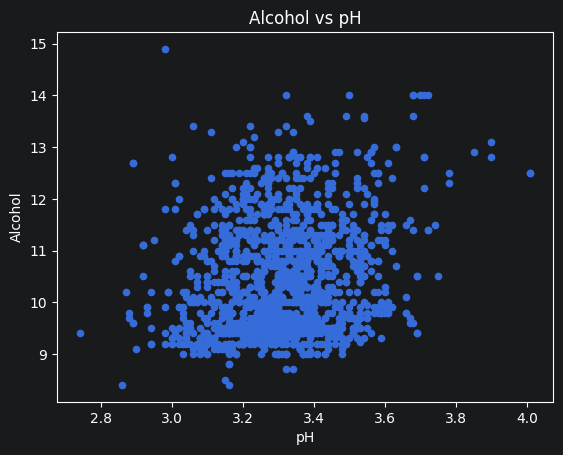

In [14]:
# YOUR CODE HERE
df.plot.scatter(
    x="pH",
    y="alcohol",
    xlabel="pH",
    ylabel="Alcohol",
    title="Alcohol vs pH"
)

### Challenge 3: Total acidity vs pH, scatter plot

Create a scatter plot of `total_acidity` (y-axis) against `pH` (x-axis). Does there appear to be any relationship? Does the direction of the relationship make intuitive sense?

<Axes: title={'center': 'Total Acidity vs pH'}, xlabel='pH', ylabel='Total Acidity'>

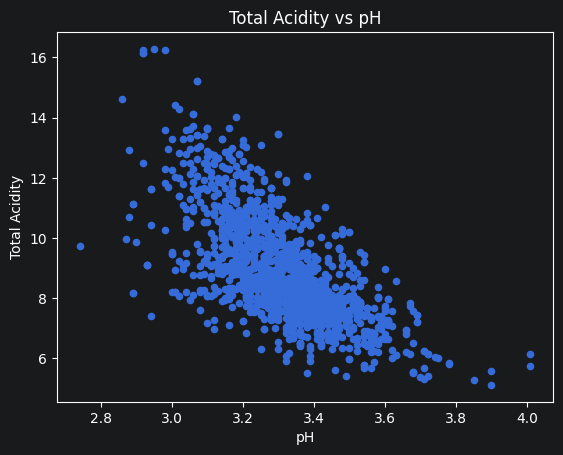

In [15]:
# YOUR CODE HERE
df.plot.scatter(
    x="pH",
    y="total_acidity",
    xlabel="pH",
    ylabel="Total Acidity",
    title="Total Acidity vs pH"
)

### Challenge 4: Distribution of quality, histogram

Plot a histogram of the `quality` column. Are the quality scores evenly distributed across the dataset?

<Axes: title={'center': 'Distribution of Wine Quality Scores'}, ylabel='Frequency'>

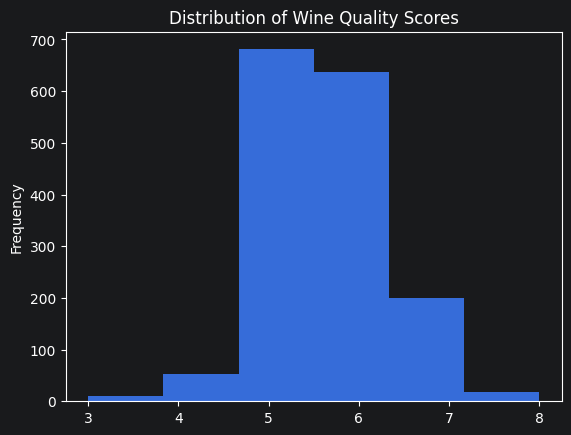

In [12]:
# YOUR CODE HERE
df["quality"].plot.hist(bins=6, title="Distribution of Wine Quality Scores")

### Challenge 5: Distribution of citric acid, box plot

Create a box plot for the `citric acid` column. What can you say about its distribution? Are there any outliers?

<Axes: title={'center': 'Box Plot of Citric Acid'}>

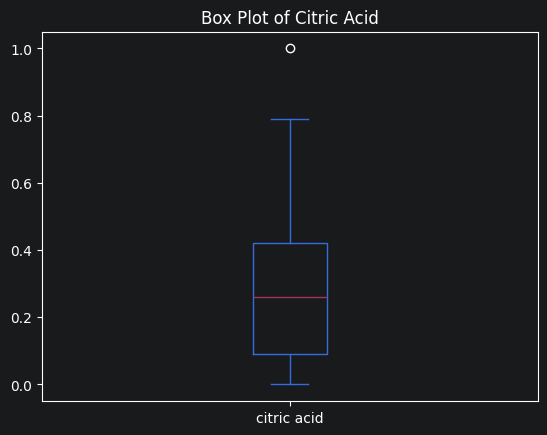

In [16]:
# YOUR CODE HERE
df["citric acid"].plot.box(title="Box Plot of Citric Acid")

---

## Key Takeaways

- Use **`.plot(kind='hist')`** to see the distribution of a single variable

- Use **`.plot(kind='scatter', x=..., y=...)`** to explore relationships between two variables

- Use **`.plot(kind='box')`** to compare spread and spot outliers

- Use **`.plot(kind='bar')`** after a `groupby` to visualise aggregated categories

- Combine Pandas data operations with `.plot()` for quick, powerful EDA

- When columns have very different scales, select a subset before plotting

---

## Check Your Understanding

1. What does a histogram tell you that `.describe()` does not?

<details>
<summary>Show answer</summary>

`.describe()` summarises a column with a handful of numbers, count, mean, std, min, max, and three quartiles. A histogram shows the *shape* of the distribution: how many points fall in each value range. Two columns can share an identical `.describe()` output and still look completely different, one bell-shaped, one bimodal, one heavily skewed. The picture surfaces structure (gaps, peaks, outliers) that the seven-number summary hides.
</details>

2. You want to see if higher alcohol content is associated with higher quality. Which chart type would you use?

<details>
<summary>Show answer</summary>

This is a question about the relationship between **two numeric variables**, so a **scatter plot** is the right tool, each point is one wine, with alcohol on the x-axis and quality on the y-axis. The pattern of the cloud (sloping up, flat, no relationship) answers the question visually. If quality is treated as a discrete category instead, a box plot of alcohol grouped by quality level also works well. A histogram won't help here because it only shows one variable at a time.
</details>

3. A box plot shows a very long upper whisker on one column. What does that suggest?

<details>
<summary>Show answer</summary>

The whisker stretches out to capture values that sit far above the 75th percentile but still inside the "non-outlier" range (typically 1.5 × IQR beyond Q3). A long upper whisker means the distribution is **right-skewed**, most values cluster near the median, but a meaningful tail of larger values stretches upward. It's a hint to investigate that tail: real heavy-tailed behaviour, a few unusually large entries, or a data-entry issue.
</details>

4. Why is it a problem to plot all columns together when they have very different scales?

<details>
<summary>Show answer</summary>

Matplotlib uses a single y-axis by default, so the column with the largest range dominates the chart and squashes everything else into a flat line near zero. You lose the ability to read the smaller columns entirely. Fixes include scaling each column first (`StandardScaler`, min-max), using a secondary y-axis, or plotting each column in its own subplot. Faceted small multiples are usually the cleanest answer.
</details>

### **Continue to:** [Notebook_4](04_More_Pandas_Practice.ipynb)